In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

In [2]:
top5_funds = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

top5_funds

[120507, 120844, 101208, 100025, 119120]

In [4]:
returns_df = pd.DataFrame()

for fund in top5_funds:

    temp = (
        nav_history[
            nav_history["amfi_code"] == fund
        ]
        .sort_values("date")
        .copy()
    )

    temp["daily_return"] = (
        temp["nav"]
        .pct_change()
    )

    returns_df[str(fund)] = (
        temp["daily_return"]
        .reset_index(drop=True)
    )
returns_df = returns_df.dropna()

returns_df.head()

,120507,120844,101208,100025,119120
1,0.000480,0.000243,-0.000141,-0.003553,0.002651
2,0.000657,0.000462,0.000382,-0.000050,0.004416
3,0.000136,0.000650,-0.000143,-0.001880,0.003598
4,0.000611,0.000176,0.000215,0.002036,-0.002465
5,0.000958,0.000853,0.000690,0.006791,-0.000353


In [6]:
mean_returns = (
    returns_df.mean()
    * 252
)

cov_matrix = (
    returns_df.cov()
    * 252
)
num_portfolios = 5000

results = np.zeros(
    (
        3,
        num_portfolios
    )
)

weights_record = []

In [7]:
for i in range(num_portfolios):

    weights = np.random.random(
        len(top5_funds)
    )

    weights /= np.sum(weights)

    weights_record.append(weights)

    portfolio_return = np.sum(
        weights
        * mean_returns
    )

    portfolio_std = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix,
                weights
            )
        )
    )

    sharpe = (
        portfolio_return
        / portfolio_std
    )

    results[0, i] = portfolio_return
    results[1, i] = portfolio_std
    results[2, i] = sharpe

In [8]:
portfolio_df = pd.DataFrame(
    {
        "Return": results[0],
        "Risk": results[1],
        "Sharpe": results[2]
    }
)

portfolio_df.head()

,Return,Risk,Sharpe
0,0.059955,0.013844,4.330668
1,0.054237,0.016694,3.248930
2,0.057684,0.014062,4.102024
3,0.057884,0.010865,5.327695
4,0.058280,0.011728,4.969216


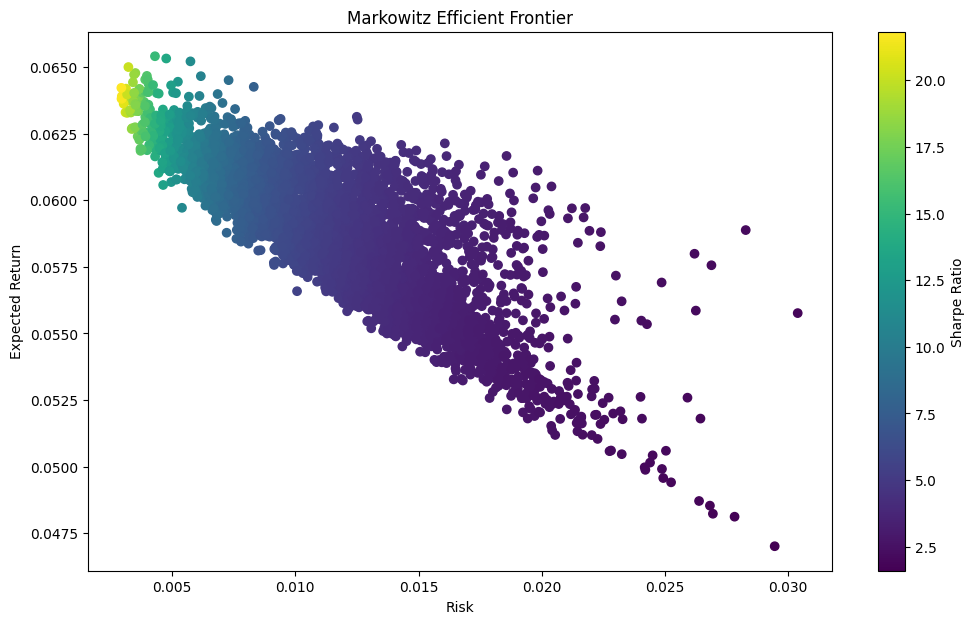

In [11]:
plt.figure(figsize=(12,7))

plt.scatter(
    portfolio_df["Risk"],
    portfolio_df["Return"],
    c=portfolio_df["Sharpe"],
    cmap="viridis"
)

plt.colorbar(
    label="Sharpe Ratio"
)

plt.xlabel("Risk")

plt.ylabel("Expected Return")

plt.title(
    "Markowitz Efficient Frontier"
)

plt.show()


In [12]:
best_portfolio = portfolio_df.loc[
    portfolio_df["Sharpe"].idxmax()
]

best_portfolio

Return     0.064215
Risk       0.002943
Sharpe    21.820825
Name: 4983, dtype: float64

### Portfolio Optimization

A Markowitz portfolio optimization model was developed using the top-performing mutual funds. Thousands of portfolio combinations were simulated to identify the risk-return trade-off and determine the portfolio with the highest Sharpe Ratio. The efficient frontier highlights optimal portfolios that maximize returns for a given level of risk.